# GHaLIB غالب: Generating Hope and Linguistic Irony in Banter

### **Setting Modules**

In [1]:
!git clone https://github.com/urduhack/urduhack.git

Cloning into 'urduhack'...
remote: Enumerating objects: 1432, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 1432 (delta 2), reused 5 (delta 2), pack-reused 1408 (from 1)
Receiving objects: 100% (1432/1432), 496.64 KiB | 5.02 MiB/s, done.
Resolving deltas: 100% (801/801), done.


In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer
from typing import FrozenSet
from wordcloud import WordCloud
import re
import string
import nltk
import zipfile
import os
from urllib import request
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import ElectraTokenizer, ElectraForMaskedLM
from transformers import RobertaTokenizer, RobertaModel
from transformers import BertTokenizer, BertModel
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import warnings
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SVMSMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score
import torch.nn as nn

warnings.filterwarnings("ignore", message="Some weights of RobertaModel were not initialized from the model checkpoint")

### **Text Preprocessing**

In [2]:
STOP_WORDS: FrozenSet[str] = frozenset("""

 آ آئی آئیں آئے آتا آتی آتے آس آمدید آنا آنسہ آنی آنے آپ آگے آہ آہا آیا اب ابھی ابے
 ارے اس اسکا اسکی اسکے اسی اسے اف افوہ البتہ الف ان اندر انکا انکی انکے انہوں انہی انہیں اوئے اور اوپر
 اوہو اپ اپنا اپنوں اپنی اپنے اپنےآپ اکثر اگر اگرچہ اہاہا ایسا ایسی ایسے ایک بائیں بار بارے بالکل باوجود باہر
 بج بجے بخیر بشرطیکہ بعد بعض بغیر بلکہ بن بنا بناؤ بند بڑی بھر بھریں بھی بہت بہتر تاکہ تاہم تب تجھ
 تجھی تجھے ترا تری تلک تم تمام تمہارا تمہاروں تمہاری تمہارے تمہیں تو تک تھا تھی تھیں تھے تیرا تیری تیرے
 جا جاؤ جائیں جائے جاتا جاتی جاتے جانی جانے جب جبکہ جدھر جس جسے جن جناب جنہوں جنہیں جو جہاں جی جیسا
 جیسوں جیسی جیسے حالانکہ حالاں حصہ حضرت خاطر خالی خواہ خوب خود دائیں درمیان دریں دو دوران دوسرا دوسروں دوسری دوں
 دکھائیں دی دیئے دیا دیتا دیتی دیتے دیر دینا دینی دینے دیکھو دیں دیے دے ذریعے رکھا رکھتا رکھتی رکھتے رکھنا رکھنی
 رکھنے رکھو رکھی رکھے رہ رہا رہتا رہتی رہتے رہنا رہنی رہنے رہو رہی رہیں رہے ساتھ سامنے ساڑھے سب سبھی
 سراسر سمیت سوا سوائے سکا سکتا سکتے سہ سہی سی سے شاید شکریہ صاحب صاحبہ صرف ضرور طرح طرف طور علاوہ عین
 فقط فلاں فی قبل قطا لئے لائی لائے لاتا لاتی لاتے لانا لانی لانے لایا لو لوجی لوگوں لگ لگا لگتا
 لگتی لگی لگیں لگے لہذا لی لیا لیتا لیتی لیتے لیکن لیں لیے لے ماسوا مت مجھ مجھی مجھے محترم محترمہ محض
 مرا مرحبا مری مرے مزید مس مسز مسٹر مطابق مل مکرمی مگر مگھر مہربانی میرا میروں میری میرے میں نا نزدیک
 نما نہ نہیں نیز نیچے نے و وار واسطے واقعی والا والوں والی والے واہ وجہ ورنہ وغیرہ ولے وگرنہ وہ وہاں
 وہی وہیں ویسا ویسے ویں پاس پایا پر پس پلیز پون پونی پونے پھر پہ پہلا پہلی پہلے پیر پیچھے چاہئے
 چاہتے چاہیئے چاہے چلا چلو چلیں چلے چناچہ چند چونکہ چکی چکیں چکے ڈالنا ڈالنی ڈالنے ڈالے کئے کا کاش کب کبھی
 کدھر کر کرتا کرتی کرتے کرم کرنا کرنے کرو کریں کرے کس کسی کسے کم کن کنہیں کو کوئی کون کونسا
 کونسے کچھ کہ کہا کہاں کہہ کہی کہیں کہے کی کیا کیسا کیسے کیونکر کیونکہ کیوں کیے کے گئی گئے گا گنا
 گو گویا گی گیا ہائیں ہائے ہاں ہر ہرچند ہرگز ہم ہمارا ہماری ہمارے ہمی ہمیں ہو ہوئی ہوئیں ہوئے ہوا
 ہوبہو ہوتا ہوتی ہوتیں ہوتے ہونا ہونگے ہونی ہونے ہوں ہی ہیلو ہیں ہے یا یات یعنی یک یہ یہاں یہی یہیں
""".split())

def remove_stopwords(text: str) -> str:
    return " ".join(word for word in text.split() if word not in STOP_WORDS)

In [3]:
def clean_urdu_text(text):
    text = re.sub(r"[ًٌٍَُِّْ]", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_english_text(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)  
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    stopwords_ = ['user', 'br']
    words = [word for word in words if word not in stopwords_]

    return " ".join(words)

In [4]:
text = "???یہ ایک مثال ہے"
print(clean_urdu_text(text))

text = "This is samplE TexT??"
print(clean_english_text(text))

یہ ایک مثال ہے
this is sample text


### **Loading**

In [119]:
ur_train  = pd.read_csv('../input/polyhope-iberlef-2025/Ur_train.csv')
ur_dev = pd.read_csv('../input/polyhope-iberlef-2025/Ur_dev.csv')
ur_test = pd.read_csv('../input/polyhope-iberlef-2025/Ur_test_without_labels.csv')

ur_train.head()

,text,binary,multiclass
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope


In [120]:
en_train  = pd.read_csv('../input/polyhope-iberlef-2025/en_train.csv')
en_dev = pd.read_csv('../input/polyhope-iberlef-2025/en_dev.csv')
en_test = pd.read_csv('../input/polyhope-iberlef-2025/en_test_without_labels.csv')

en_train.head()

,text,binary,multiclass
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope


In [121]:
en_train['cleaned text'] = en_train['text'].apply(clean_english_text)
ur_train['cleaned text'] = ur_train['text'].apply(clean_urdu_text)

en_test['cleaned text'] = en_test['text'].apply(clean_english_text)
ur_test['cleaned text'] = ur_test['text'].apply(clean_urdu_text)

en_dev['cleaned text'] = en_dev['text'].apply(clean_english_text)
ur_dev['cleaned text'] = ur_dev['text'].apply(clean_urdu_text)

In [122]:
en_train.head()

,text,binary,multiclass,cleaned text
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope,you expect a man that literally refers to hims...
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope,tinubu is actually a bonus lols his only hope ...
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope,anyway love u bubbly i know i can count on you...
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope,you have a lot of people rooting for you wheth...
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope,hoping to get on the brown a lot more after i ...


In [123]:
ur_train.head()

,text,binary,multiclass,cleaned text
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope,پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ تو بدلش...
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope,خاتمالنبیینمحمدسیشن شاناولیاءکرامرحمتہاللہعلیہ...
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope,میں مانتا ہوں کہ مریم مرڈوک کے سیکرٹری اس فلم ...
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...


### **Getting MultiLingBERT Embeddings**

In [124]:
def get_embeddings(text, tokenizer, model, device):
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    encoded_input = {key: val.to(device) for key, val in encoded_input.items()}
    with torch.no_grad():
        output = model(**encoded_input)
    last_hidden_state = output.last_hidden_state
    sentence_embedding = last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return sentence_embedding

In [125]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_en = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model_en = BertModel.from_pretrained("bert-base-multilingual-cased").to(device)

tqdm.pandas()
en_train['embedding'] = en_train['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_en, model_en, device))
en_test['embedding'] = en_test['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_en, model_en, device))
en_dev['embedding'] = en_dev['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_en, model_en, device))

100%|██████████| 1650/1650 [00:13<00:00, 120.84it/s]


In [126]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#tokenizer_ur = AutoTokenizer.from_pretrained("urduhack/roberta-urdu-small")
#model_ur = AutoModel.from_pretrained("urduhack/roberta-urdu-small").to(device)

#tokenizer_ur = AutoTokenizer.from_pretrained("mahwizzzz/UrduBert")
#model_ur = AutoModel.from_pretrained("mahwizzzz/UrduBert").to(device)

tokenizer_ur = tokenizer_en
model_ur = model_en

tqdm.pandas()
ur_train['embedding'] = ur_train['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_ur, model_ur, device))
ur_test['embedding'] = ur_test['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_ur, model_ur, device))
ur_dev['embedding'] = ur_dev['text'].progress_apply(lambda x: get_embeddings(x, tokenizer_ur, model_ur, device))

100%|██████████| 1678/1678 [00:28<00:00, 57.95it/s]


In [127]:
en_train.head()

,text,binary,multiclass,cleaned text,embedding
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope,you expect a man that literally refers to hims...,"[-0.15296571, -0.1978182, -0.1862663, 0.231555..."
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope,tinubu is actually a bonus lols his only hope ...,"[-0.14332329, -0.61096483, -0.11747553, 0.2819..."
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope,anyway love u bubbly i know i can count on you...,"[0.28418645, -0.12847833, -0.052789707, 0.2013..."
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope,you have a lot of people rooting for you wheth...,"[-0.2856133, -0.25653824, 0.12884904, 0.460513..."
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope,hoping to get on the brown a lot more after i ...,"[-0.07661525, -0.09866947, 0.0670913, 0.055113..."


In [128]:
ur_train.head()

,text,binary,multiclass,cleaned text,embedding
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope,پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ تو بدلش...,"[0.09038348, -0.33199647, 0.67794937, 0.326969..."
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope,خاتمالنبیینمحمدسیشن شاناولیاءکرامرحمتہاللہعلیہ...,"[0.13228099, -0.33811828, 0.84404284, 0.287229..."
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,"[-0.22264576, -0.42783213, 0.39730203, 0.00524..."
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope,میں مانتا ہوں کہ مریم مرڈوک کے سیکرٹری اس فلم ...,"[-0.20222907, -0.43885252, 0.3777865, 0.042596..."
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,"[-0.1449618, -0.32188776, 0.4128196, 0.0031421..."


### **Storing Embeddings Sparsed**

In [129]:
embedding_df = pd.DataFrame(en_train['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_train = pd.concat([en_train, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_train['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_train = pd.concat([ur_train, embedding_df], axis=1)

embedding_df = pd.DataFrame(en_test['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_test = pd.concat([en_test, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_test['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_test = pd.concat([ur_test, embedding_df], axis=1)

embedding_df = pd.DataFrame(en_dev['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_dev = pd.concat([en_dev, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_dev['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_dev = pd.concat([ur_dev, embedding_df], axis=1)

In [130]:
en_train.iloc[:, 5:].head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,-0.152966,-0.197818,-0.186266,0.231556,0.604056,-0.062854,-0.422196,0.109415,0.074114,0.433450,...,0.016304,-0.025079,-0.833294,-0.469293,0.276766,-0.375850,0.429563,0.893841,-0.334925,-0.306454
1,-0.143323,-0.610965,-0.117476,0.281908,0.729291,0.043532,-0.127750,0.075849,-0.003712,-0.166832,...,0.027616,0.284389,-0.440632,-0.350874,0.487202,-0.165477,0.452704,0.729515,-0.003472,-0.196238
2,0.284186,-0.128478,-0.052790,0.201312,0.593505,-0.181646,-0.752137,-0.235883,0.458717,0.268470,...,0.033335,0.185536,-0.846578,-0.480496,0.274778,-0.379222,0.227352,0.587369,-0.307887,-0.122345
3,-0.285613,-0.256538,0.128849,0.460514,0.458771,0.238015,-0.502915,-0.028251,0.083707,0.140191,...,0.156372,-0.043006,-0.363828,-0.961045,0.216304,-0.479564,0.240656,0.462793,-0.120563,-0.064683
4,-0.076615,-0.098669,0.067091,0.055113,0.454547,-0.135968,-0.493331,0.220831,0.079666,-0.592735,...,-0.214295,0.169752,-0.341132,-0.140704,-0.262384,-0.240846,0.678443,0.272322,-0.433209,0.070824


In [131]:
ur_train.iloc[:, 5:].head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,0.090383,-0.331996,0.677949,0.326969,0.404553,-0.047702,-0.146066,0.405053,0.095926,0.261154,...,0.251447,0.365281,-0.451827,-0.417131,0.258589,0.401066,0.053677,0.540863,-0.141357,0.097424
1,0.132281,-0.338118,0.844043,0.287230,0.583885,0.092010,-0.488962,0.409575,0.048917,0.154847,...,0.565343,-0.261485,-1.214449,-0.707349,-0.055529,-0.145754,0.145796,0.445369,0.378846,-0.508031
2,-0.222646,-0.427832,0.397302,0.005248,0.254489,0.179027,-0.082994,0.531036,-0.195599,0.053690,...,0.250854,-0.027249,-0.324633,-0.738672,-0.016667,0.212904,0.020205,0.369774,-0.015562,-0.195516
3,-0.202229,-0.438853,0.377786,0.042597,0.172381,0.115868,-0.090467,0.510725,-0.223046,0.148132,...,0.249903,0.052515,-0.369856,-0.886679,-0.121566,0.115310,0.096878,0.469862,-0.070953,-0.182578
4,-0.144962,-0.321888,0.412820,0.003142,0.373165,0.097982,-0.075695,0.426710,-0.073351,0.062835,...,0.156979,0.072595,-0.440143,-0.832846,-0.036430,0.230241,-0.016329,0.463981,-0.023708,-0.178307


### **Training Models**

#### **Data Splitting**

In [132]:
X_ur = ur_train.iloc[:, 5:]
X_en = en_train.iloc[:, 5:]

ss = StandardScaler()

X_ur_test = ur_test.iloc[:, 3:]
X_ur_test_text = ur_test['text']

X_en_test = en_test.iloc[:, 3:]
X_en_test_text = en_test['text']

X_ur = ss.fit_transform(X_ur)
X_en = ss.fit_transform(X_en)
X_ur_test = ss.fit_transform(X_ur_test)
X_en_test = ss.fit_transform(X_en_test)

y_ur_mc = ur_train['multiclass']
y_ur_bin = ur_train['binary']

y_en_mc = en_train['multiclass']
y_en_bin = en_train['binary']


X_ur_dev = ur_dev.iloc[:, 5:]
X_en_dev = en_dev.iloc[:, 5:]

X_ur_dev = ss.fit_transform(X_ur_dev)
X_en_dev = ss.fit_transform(X_en_dev)

y_ur_bin_dev = ur_dev['binary']
y_en_bin_dev = en_dev['binary']
y_ur_mc_dev = ur_dev['multiclass']
y_en_mc_dev = en_dev['multiclass']

In [133]:
models = {
    "Urdu MC": (X_ur, y_ur_mc, X_ur_dev, y_ur_mc_dev,X_ur_test, X_ur_test_text),
    "English MC": (X_en, y_en_mc, X_en_dev, y_en_mc_dev,X_en_test, X_en_test_text),
    "Urdu Bin": (X_ur, y_ur_bin, X_ur_dev, y_ur_bin_dev, X_ur_test, X_ur_test_text),
    "English Bin": (X_en, y_en_bin, X_en_dev, y_en_bin_dev,X_en_test, X_en_test_text),
}

In [134]:
def classification_report(y_true, y_pred):
    accuracy = round(accuracy_score(y_true, y_pred), 2)
    avg_f1 = round(f1_score(y_true, y_pred, average="macro"), 2)
    
    return pd.DataFrame({
        "Metric": ["Accuracy", "F1-Macro"],
        "Value": [accuracy, avg_f1]
    })

100%|██████████| 4/4 [00:41<00:00, 10.44s/it]


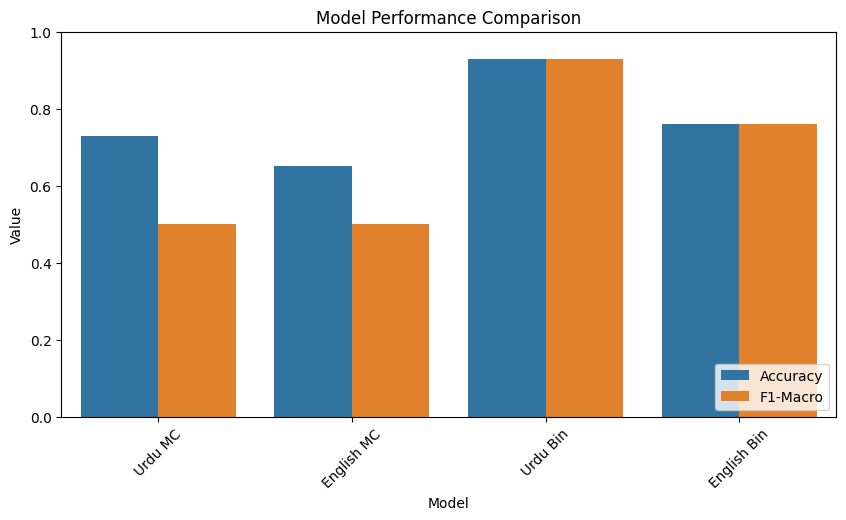

In [138]:
results = []

for name, (X_train, y_train, X_test, y_test, X_test_final, X_test_text) in tqdm(models.items()):
    model = SVC()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    report["Model"] = name

    y_pred = model.predict(X_test_final) 
    predictions = pd.DataFrame({'Text':X_test_text, 'Tag':y_pred})
    predictions.to_csv(f'{name}.csv', index = False)
    results.append(report)

df = pd.concat(results).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

In [139]:
df

,Metric,Value,Model
0,Accuracy,0.73,Urdu MC
1,F1-Macro,0.50,Urdu MC
2,Accuracy,0.65,English MC
3,F1-Macro,0.50,English MC
4,Accuracy,0.93,Urdu Bin
5,F1-Macro,0.93,Urdu Bin
6,Accuracy,0.76,English Bin
7,F1-Macro,0.76,English Bin


100%|██████████| 4/4 [01:29<00:00, 22.42s/it]


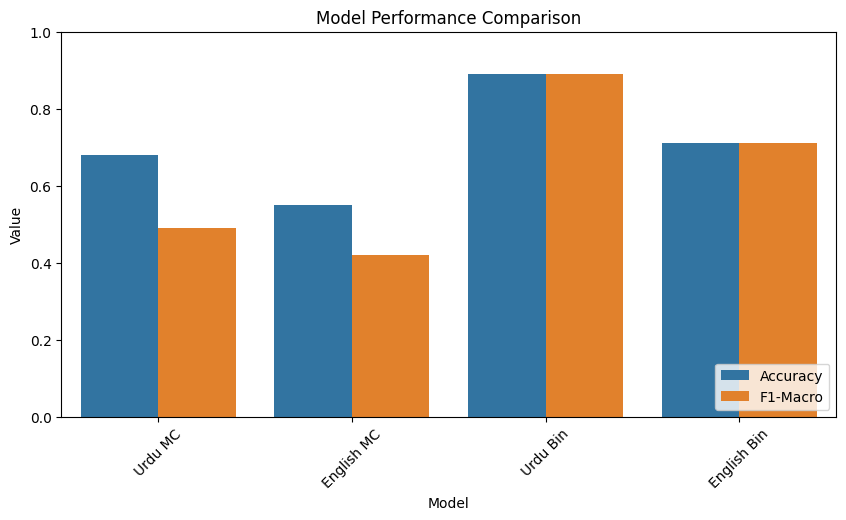

In [136]:
results = []

for name, (X_train, y_train, X_test, y_test, X_test_final, X_test_text) in tqdm(models.items()):
    model = AdaBoostClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    report["Model"] = name

    y_pred = model.predict(X_test_final) 
    predictions = pd.DataFrame({'Text':X_test_text, 'Tag':y_pred})
    predictions.to_csv(f'{name}.csv', index = False)
    results.append(report)

df = pd.concat(results).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

In [137]:
df

,Metric,Value,Model
0,Accuracy,0.68,Urdu MC
1,F1-Macro,0.49,Urdu MC
2,Accuracy,0.55,English MC
3,F1-Macro,0.42,English MC
4,Accuracy,0.89,Urdu Bin
5,F1-Macro,0.89,Urdu Bin
6,Accuracy,0.71,English Bin
7,F1-Macro,0.71,English Bin
